In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import mlflow
import mlflow.sklearn

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("Credit Risk Prediction")


SyntaxError: incomplete input (2935276393.py, line 5)

In [29]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(y_train.shape)
print(y_test.shape)

X_train: (24000, 23)
X_test: (6000, 23)
y_train: (24000, 1)
y_test: (6000, 1)
(24000,)
(6000,)


In [30]:
with mlflow.start_run():

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    y_prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", accuracy)

    print("ROC-AUC:", auc)

    print(classification_report(y_test, y_pred))

Accuracy: 0.7826666666666666
ROC-AUC: 0.6466218496772573
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.73      0.03      0.05      1327

    accuracy                           0.78      6000
   macro avg       0.75      0.51      0.47      6000
weighted avg       0.77      0.78      0.70      6000



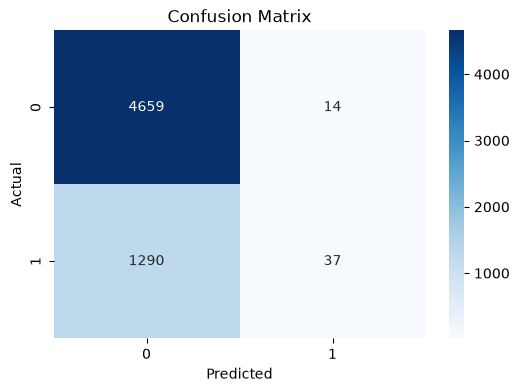

In [31]:
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.savefig("../reports/confusion_matrix.png")

    plt.show()

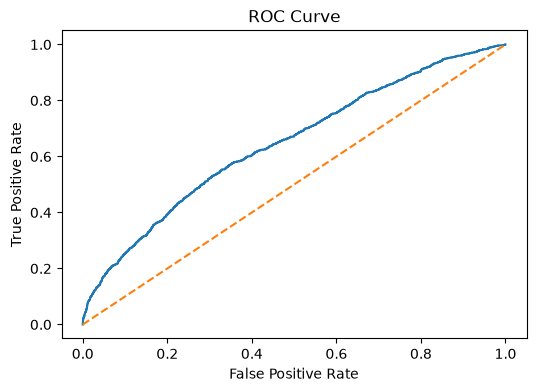

In [32]:
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(6,4))

    plt.plot(fpr,tpr)

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.savefig("../reports/roc_curve.png")

    plt.show()

In [33]:
    joblib.dump(
        model,
        "../models/logistic_regression.pkl"
    )

    loaded_model = joblib.load(
        "../models/logistic_regression.pkl"
    )

    print("Model Loaded Successfully")

Model Loaded Successfully


In [34]:
    mlflow.log_param(
        "model",
        "Logistic Regression"
    )

    mlflow.log_param(
        "max_iter",
        1000
    )

    mlflow.log_param(
        "random_state",
        42
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "precision",
        precision
    )

    mlflow.log_metric(
        "recall",
        recall
    )

    mlflow.log_metric(
        "f1_score",
        f1
    )

    mlflow.log_metric(
        "roc_auc",
        auc
    )

    mlflow.log_artifact("../reports/confusion_matrix.png")

    mlflow.log_artifact("../reports/roc_curve.png")

    mlflow.sklearn.log_model(
        model,
        "logistic_regression_model"
    )

2026/06/25 23:58:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [40]:
import mlflow

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:////home/nevin/FinGuard-AI/notebooks/mlflow.db


In [41]:
client = mlflow.tracking.MlflowClient()

experiments = client.search_experiments()

for exp in experiments:
    print(exp.experiment_id, exp.name)

1 Credit Risk Prediction
0 Default


In [42]:
client = mlflow.tracking.MlflowClient()

for exp in client.search_experiments():
    runs = client.search_runs([exp.experiment_id])
    print(f"\nExperiment: {exp.name}")
    print("Number of runs:", len(runs))


Experiment: Credit Risk Prediction
Number of runs: 8

Experiment: Default
Number of runs: 0
